Thuesday July 2nd:

Up to this point I was only recreating Figure 3 From Zhang 2023 (https://ui.adsabs.harvard.edu/abs/2023ApJ...953...96Z/abstract). I have sorted out the issue with albedo and effective albedo, but now the polarization does not line up. 

To hopefully sort out this issue, I am going to take a step back and hopefully figure out the polarization issues by recreating earlier plots in the paper.

# Loading packages

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packa

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
from matplotlib.ticker import LogLocator, NullLocator

# Parameters

In [4]:
f_values = [1, 0.3, 0.1, 0.01]
colours = ['C0', 'C1', 'C2', 'C3']

# Figure 1

In [5]:
N = 500
lam_cm = np.logspace(-5, 1, N)

In [6]:
# Single Particle
SP_lambda = []
SP_kabs = []
SP_ksca = []
SP_ksca_eff = []

for f in (f_values):
    
    # Running first time
    # ------------------------------------------------------------
#     a_micron = 160 / f
#     a_cm = np.array([micron_to_cm(a_micron)])
    
#     print(f'f = {f} and a*f = {a_micron * f}')
    
#     # run DSHARP
#     oc, rho_g_cm3 = do.get_dsharp_mix(porosity = 1 - f)
    
#     res = do.get_opacities(a_cm, lam_cm, rho_g_cm3, oc)
    
    
#     np.savez(
#     f"Fig2Top_porosity_{f:.2f}.npz",
#     a_cm=a_cm,
#     lam=lam_cm,
#     k_abs=res["k_abs"],
#     k_sca=res["k_sca"],
#     g=res["g"]
#     )
    # ------------------------------------------------------------
    
    # Running second time
    # ------------------------------------------------------------
    
    data = np.load(f"Fig2Top_porosity_{f:.2f}.npz")

    k_abs = data["k_abs"]
    k_sca = data["k_sca"]
    g = data["g"]
    
    SP_kabs.append(data["k_abs"][0])
    SP_ksca.append(data["k_sca"][0])
    SP_ksca_eff.append((1 - data["g"][0]) * data["k_sca"][0])
    # ------------------------------------------------------------

In [7]:
# Particle Size Distribution 

# Single Particle 

PD_kabs = [] 
PD_ksca = [] 
PD_ksca_eff = [] 

amin_cm = micron_to_cm(0.1) 

f_values_short = [1, 0.3, 0.1]
for f in (f_values_short): 
    # Running first time 
    # ------------------------------------------------------------ 
    # a * f = 160 micron a_micron = 160 / f amax_cm = micron_to_cm(a_micron) 
#     a_grid = np.logspace(np.log10(amin_cm), np.log10(amax_cm), N) 
    
#     # run DSHARP 
#     oc, rho_g_cm3 = do.get_dsharp_mix(porosity=1-f) 
    
#     # Compute opacities for EVERY grain size 
    
#     res = do.get_opacities( a_grid, lam_cm, rho_g_cm3, oc) 
    
#     np.savez( f"Fig2Bottom_porosity_{f:.2f}.npz", 
#              a=a_grid, 
#              lam=lam_cm, 
#              k_abs=res["k_abs"], 
#              k_sca=res["k_sca"], 
#              g=res["g"] ) 
    # ------------------------------------------------------------ 
    
    # Running second time 
    # ------------------------------------------------------------ 
    data2 = np.load(f"Fig2Bottom_porosity_{f:.2f}.npz") 
    
    a_grid = data2["a"] 
#     k_abs = data2["k_abs"] 
#     k_sca = data2["k_sca"] 
#     g = data2["g"] 
    
    # q = 3.5 
    weights = a_grid**0.5 
    
    weights /= weights.sum() 
    
    kabs_avg = np.sum(data2["k_abs"] * weights[:, None], axis=0) 
    
    ksca_avg = np.sum(data2["k_sca"] * weights[:, None], axis=0) 
    
    g_avg = ( np.sum(data2["g"] * data2["k_sca"] * weights[:, None], axis=0) / ksca_avg ) 
    
    PD_kabs.append(kabs_avg) 
    
    PD_ksca.append(ksca_avg) 
    
    PD_ksca_eff.append((1 - g_avg) * ksca_avg) 
    # ----------------------------------------------------------

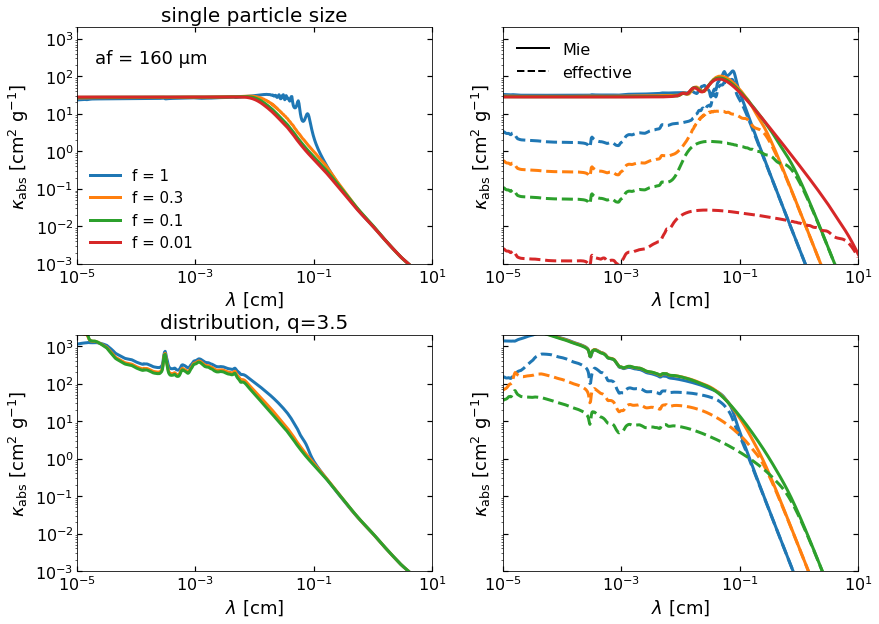

In [8]:
# Make the plot
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

lw = 3
legend_fs = 15


legend_lines = [
    Line2D([0], [0], color='k', lw=2, linestyle='-'),
    Line2D([0], [0], color='k', lw=2, linestyle='--')
]

    
# Top left 
for i in range(4):
    ax[0, 0].plot(lam_cm, SP_kabs[i], color = colours[i], lw = lw, label = f'f = {f_values[i]}')
ax[0, 0].text(0.05, 0.85, 'af = 160 μm', fontsize=18, transform=ax[0, 0].transAxes)
ax[0, 0].set_title('single particle size', fontsize=20)
ax[0,0].set_ylabel(r'$\kappa_{\rm abs}\ [{\rm cm^2\ g^{-1}}]$', fontsize=18)
ax[0, 0].legend(fontsize = legend_fs, loc = 'lower left', frameon = False)



# Top right 
for i in range(4):
    ax[0, 1].plot(lam_cm, SP_ksca[i], color = colours[i], lw = lw, ls = '-')
    ax[0, 1].plot(lam_cm, SP_ksca_eff[i], color = colours[i], lw = lw, ls = '--')
    
ax[0, 1].set_ylabel(r'$\kappa_{\rm abs}\ [{\rm cm^2\ g^{-1}}]$', fontsize=18)
ax[0, 1].tick_params(labelleft=False)
ax[0,1].legend(
    legend_lines,
    ['Mie', 'effective'],
    frameon=False,
    fontsize=16,
    loc='upper left'
)


# Bottom left
for i in range(3):
    ax[1, 0].plot(lam_cm, PD_kabs[i], color = colours[i], lw = lw, label = f'f = {f_values[i]}')
ax[1, 0].set_ylabel(r'$\kappa_{\rm abs}\ [{\rm cm^2\ g^{-1}}]$', fontsize=18)
ax[1,0].set_title('distribution, q=3.5', fontsize=20)




# Bottom right 
for i in range(3):
    ax[1, 1].plot(lam_cm, PD_ksca[i], color = colours[i], lw = lw, ls = '-')
    ax[1, 1].plot(lam_cm, PD_ksca_eff[i], color = colours[i], lw = lw, ls = '--')
ax[1, 1].set_ylabel(r'$\kappa_{\rm abs}\ [{\rm cm^2\ g^{-1}}]$', fontsize=18)
ax[1, 1].tick_params(labelleft=False)





for a in ax.ravel():

    a.set_xscale('log')
    a.set_yscale('log')

    a.set_xlim(1e-5,10)
    a.set_ylim(1e-3,2e3)

    a.tick_params(
        which='major',
        direction='in',
        top=True,
        right=True,
        length=5,
        width=1.2,
        labelsize=16
    )
    
    a.set_xlabel(r'$\lambda\ [{\rm cm}]$', fontsize=18)


plt.subplots_adjust(wspace=0.2, hspace=0.3)
    

plt.show()

# Figure 2

In [9]:
# # Particle Size Distribution 

# n = 100

# lam_cm_fig2 = np.logspace(-5, 1, n)

# # Single Particle 

# amin_cm = micron_to_cm(0.1) 

# f_values_short = [1, 0.3, 0.1]

# # maximum values 160 micron, 1mm, 1cm, 10 cm
# af_max_cm = [0.016, 0.1, 1, 10]

# af_max_cm_short = [0.016, 0.1, 1]


# Fig2_kabs = np.empty((len(af_max_cm_short), len(f_values_short)), dtype=object)
# Fig2_ksca = np.empty_like(Fig2_kabs)
# Fig2_ksca_eff = np.empty_like(Fig2_kabs)

# Fig2_Pweff = np.empty_like(Fig2_kabs)
# Fig2_P = np.empty_like(Fig2_kabs)
# Fig2_w_eff = np.empty_like(Fig2_kabs)

# for i, af_max in enumerate(af_max_cm_short):
#     for j, f in enumerate(f_values_short):

#         if f == 0.1 and af_max == 1:
#             continue

#         # -------------------------
#         # grain grid
#         amax_cm = af_max / f
#         a_grid = np.logspace(np.log10(amin_cm), np.log10(amax_cm), n)

#         oc, rho_g_cm3 = do.get_dsharp_mix(porosity=1 - f)

#         # -------------------------
#         # OPACITIES
#         res = do.get_opacities(a_grid, lam_cm_fig2, rho_g_cm3, oc)

#         k_abs = res["k_abs"]
#         k_sca = res["k_sca"]
#         g = res["g"]

#         # -------------------------
#         # SIZE WEIGHTING (κ)
#         weights = a_grid**0.5
#         weights /= weights.sum()

#         kabs_avg = np.sum(k_abs * weights[:, None], axis=0)
#         ksca_avg = np.sum(k_sca * weights[:, None], axis=0)

#         g_avg = np.sum(g * k_sca * weights[:, None], axis=0) / ksca_avg

#         omega = ksca_avg / (kabs_avg + ksca_avg)

#         # -------------------------
#         # MUELLER MATRIX (THIS IS NEW)
#         # NOTE: DSHARP needs scattering info internally
#         zscat = res["zscat"] if "zscat" in res else None

#         if zscat is None:
#             raise ValueError("Need zscat from DSHARP (must be enabled in opacity call)")

#         i90 = 0  # or correct index if theta array exists

#         Z11 = zscat[:, :, i90, 0]
#         Z12 = zscat[:, :, i90, 1]

#         Z11eff = np.sum(Z11 * weights[:, None], axis=0)
#         Z12eff = np.sum(Z12 * weights[:, None], axis=0)

#         P = np.abs(Z12eff / Z11eff)

#         # -------------------------
#         # SAVE EVERYTHING
#         np.savez(
#             f"Fig2_{i}_{j}.npz",
#             a=a_grid,
#             lam=lam_cm_fig2,
#             k_abs=k_abs,
#             k_sca=k_sca,
#             g=g,
#             kabs_avg=kabs_avg,
#             ksca_avg=ksca_avg,
#             omega=omega,
#             Z11eff=Z11eff,
#             Z12eff=Z12eff,
#             P=P
#         )
#         # ------------------------------------------------------------ 

#         # Running second time 
#         # ------------------------------------------------------------   
#         Fig2_kabs[i, j] = kabs_avg
#         Fig2_ksca[i, j] = ksca_avg
#         Fig2_ksca_eff[i, j] = ksca_eff
        
#         Fig2_w_eff[i, j] = w_eff
#         Fig2_P[i, j] = P
#         Fig2_Pweff[i, j] = P * weff
#         # ----------------------------------------------------------

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
Mie ... Done!


ValueError: Need zscat from DSHARP (must be enabled in opacity call)

In [17]:
# Particle Size Distribution 

n = 100

lam_cm_fig2 = np.logspace(-5, 1, n)

# Single Particle 

amin_cm = micron_to_cm(0.1) 

f_values_short = [1, 0.3, 0.1]

# maximum values 160 micron, 1mm, 1cm, 10 cm
af_max_cm = [0.016, 0.1, 1, 10]

af_max_cm_short = [0.016, 0.1, 1]


Fig2_kabs = np.empty((len(af_max_cm_short), len(f_values_short)), dtype=object)
Fig2_ksca = np.empty_like(Fig2_kabs)
Fig2_ksca_eff = np.empty_like(Fig2_kabs)

Fig2_Pweff = np.empty_like(Fig2_kabs)
Fig2_P = np.empty_like(Fig2_kabs)
Fig2_w_eff = np.empty_like(Fig2_kabs)

for i, af_max in enumerate(af_max_cm_short):
    for j, f in enumerate(f_values_short):

        if f == 0.1 and af_max == 1:
            continue

        # -------------------------
        # grain grid
        amax_cm = af_max / f
        a_grid = np.logspace(np.log10(amin_cm), np.log10(amax_cm), n)

        oc, rho_g_cm3 = do.get_dsharp_mix(porosity=1 - f)
        m   = 4 * np.pi / 3 * rho_g_cm3 * a_grid**3

        # -------------------------
        # OPACITIES
        res = do.get_opacities(a_grid, lam_cm_fig2, rho_g_cm3, oc)

        k_abs = res["k_abs"]
        k_sca = res["k_sca"]
        g = res["g"]
        S1    = res['S1']
        S2    = res['S2']
        theta = res['theta']

        # -------------------------
        # SIZE WEIGHTING (κ)
        weights = a_grid**0.5
        weights /= weights.sum()

        kabs_avg = np.sum(k_abs * weights[:, None], axis=0)
        ksca_avg = np.sum(k_sca * weights[:, None], axis=0)

        g_avg = np.sum(g * k_sca * weights[:, None], axis=0) / ksca_avg
        
        ksca_eff = (1 - g_avg) * ksca_avg

        omega = ksca_avg / (kabs_avg + ksca_avg)
        omega_eff = ksca_eff / (kabs_avg + ksca_eff)

        # -------------------------
        # MUELLER MATRIX (THIS IS NEW)
        # NOTE: DSHARP needs scattering info internally
        i90 = theta.searchsorted(90)
        zscat = do.calculate_mueller_matrix(lam_cm_fig2, m, S1, S2, theta=theta, k_sca=k_sca)['zscat']
        

        Z11 = zscat[:, :, i90, 0]
        Z12 = zscat[:, :, i90, 1]

        Z11eff = np.sum(Z11 * weights[:, None], axis=0)
        Z12eff = np.sum(Z12 * weights[:, None], axis=0)

        P = np.abs(Z12eff / Z11eff)

        # -------------------------
        # SAVE EVERYTHING
        np.savez(
            f"Fig2_{i}_{j}.npz",
            a=a_grid,
            lam=lam_cm_fig2,
            k_abs=k_abs,
            k_sca=k_sca,
            g=g,
            kabs_avg=kabs_avg,
            ksca_avg=ksca_avg,
            omega=omega,
            Z11eff=Z11eff,
            Z12eff=Z12eff,
            P=P
        )
        # ------------------------------------------------------------ 

        # Running second time 
        # ------------------------------------------------------------   
        Fig2_kabs[i, j] = kabs_avg
        Fig2_ksca[i, j] = ksca_avg
        Fig2_ksca_eff[i, j] = ksca_eff
        
        Fig2_w_eff[i, j] = omega_eff
        Fig2_P[i, j] = P
        Fig2_Pweff[i, j] = P * omega_eff
        # ----------------------------------------------------------

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
Mie ... Done!
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & S

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 7.8e+09%: above error tolerance
  warnings.warn(


Mie ... Done!
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
Mie ... 1 %

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 7.2e+10%: above error tolerance
  warnings.warn(


Mie ... Done!
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
Mie ... 1 %

...

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.8e+12%: above error tolerance
  warnings.warn(


Mie ... Done!
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
Mie ... 1 %

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.5e+12%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:1954: UserWarning: large size parameter: nmx=2094923.8754549897 - this can take long
  warnings.warn(


Mie ... Done!


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 3e+13%: above error tolerance
  warnings.warn(


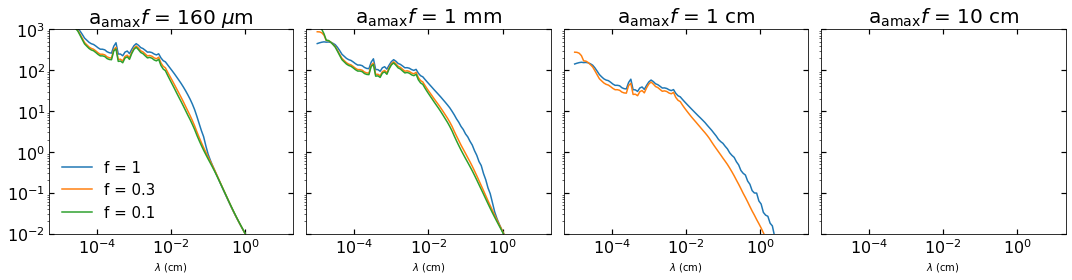

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True)



# Top row
for i in range(len(af_max_cm_short)):          # filling factors
    for j in range(len(f_values_short)):              # a_max columns
        
        if f_values_short[j] == 0.1 and af_max_cm_short[i] == 1:
            continue
        

        axes[i].plot(lam_cm_fig2, Fig2_kabs[i][j], label = f'f = {f_values_short[j]}')


axes[0].legend(fontsize = 15, frameon = False)


title_list = ['160 $\mu$m', '1 mm', '1 cm', '10 cm']

for col, a in enumerate(axes.ravel()):

    a.set_xscale('log')
    a.set_yscale('log')


    a.tick_params(
        which='major',
        direction='in',
        top=True,
        right=True,
        length=5,
        width=1.2,
        labelsize=16
    )
    
    a.set_title(rf"a$_{{\mathrm{{amax}}}}f$ = {title_list[col]}", fontsize = 20)
    a.set_xlabel("$\lambda$ (cm)")
    
    a.set_ylim(1e-2, 1e3)
    
    
    
# Loop over column
for col in range(4):
    if col in (1, 2, 3):
        axes[col].tick_params(labelleft=False)

plt.tight_layout()
plt.show()

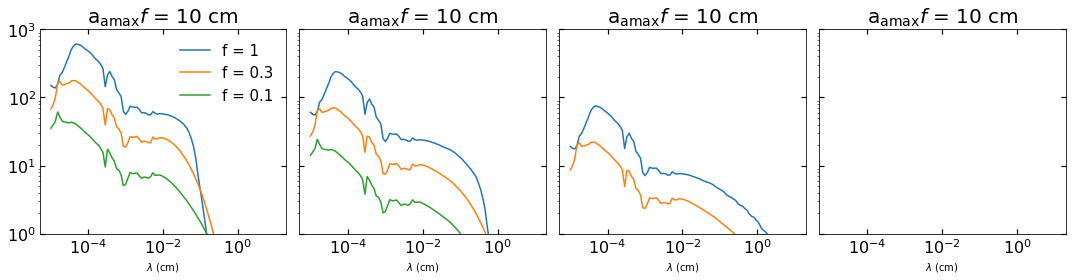

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True)



# Top row
for i in range(len(af_max_cm_short)):          # filling factors
    for j in range(len(f_values_short)):              # a_max columns
        
        if f_values_short[j] == 0.1 and af_max_cm_short[i] == 1:
            continue
        

        axes[i].plot(lam_cm_fig2, Fig2_ksca_eff[i][j], label = f'f = {f_values_short[j]}')


axes[0].legend(fontsize = 15, frameon = False)

for a in axes.ravel():

    a.set_xscale('log')
    a.set_yscale('log')


    a.tick_params(
        which='major',
        direction='in',
        top=True,
        right=True,
        length=5,
        width=1.2,
        labelsize=16
    )
    
    a.set_title(rf"a$_{{\mathrm{{amax}}}}f$ = {title_list[col]}", fontsize = 20)
    a.set_xlabel("$\lambda$ (cm)")
    
    a.set_ylim(1e0, 1e3)
    
    
    
# Loop over column
for col in range(4):
    if col in (1, 2, 3):
        axes[col].tick_params(labelleft=False)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


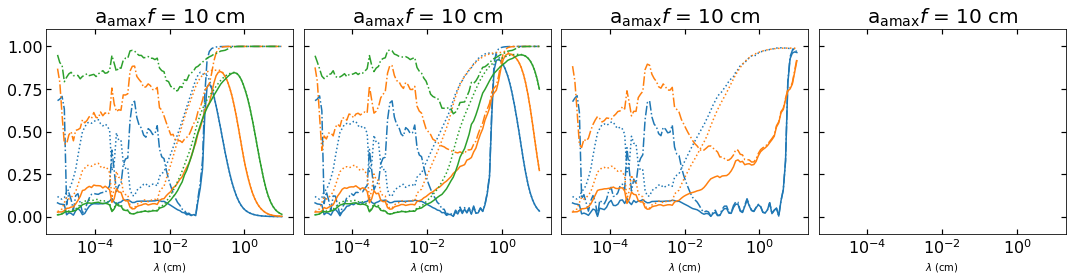

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True)



# Top row
for i in range(len(af_max_cm_short)):          # filling factors
    for j in range(len(f_values_short)):              # a_max columns
        
        if f_values_short[j] == 0.1 and af_max_cm_short[i] == 1:
            continue
        

        axes[i].plot(lam_cm_fig2, Fig2_Pweff[i][j], ls = '-', color = colours[j])
        axes[i].plot(lam_cm_fig2, Fig2_P[i][j], ls = 'dashdot', color = colours[j])
        axes[i].plot(lam_cm_fig2, Fig2_w_eff[i][j], ls = ':', color = colours[j])


axes[0].legend(fontsize = 15, frameon = False)

for a in axes.ravel():

    a.set_xscale('log')
    #a.set_yscale('log')


    a.tick_params(
        which='major',
        direction='in',
        top=True,
        right=True,
        length=5,
        width=1.2,
        labelsize=16
    )
    
    a.set_title(rf"a$_{{\mathrm{{amax}}}}f$ = {title_list[col]}", fontsize = 20)
    a.set_xlabel("$\lambda$ (cm)")
    
    a.set_ylim(-0.1, 1.1)
    
    
    
# Loop over column
for col in range(4):
    if col in (1, 2, 3):
        axes[col].tick_params(labelleft=False)

plt.tight_layout()
plt.show()